## Scaled-Space Adversarial Training — ResDNN

**Key idea**: Attack raw model with scaled inputs (all features ~N(0,1)) → eps uniform in standardized space → inverse_transform to raw for CSV output.

No `_ScaledResDNN` wrapper for attack. Instead: `PyTorchClassifier(model=resdnn_net)` with `clip_values` in scaled space.

### 1. Import packages

In [ ]:
import os, sys, time, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
import warnings
warnings.filterwarnings('ignore')

from art.estimators.classification import PyTorchClassifier

from art_generator import (
    FGSMAttackGenerator, PGDAttackGenerator, DeepFoolAttackGenerator,
    CWAttackGenerator, ZooAttackGenerator, HSJAAttackGenerator,
    MIMAttackGenerator,
)
from utils.masking import get_mutate_indices
from utils.paths import load_attack_config, load_adv_training_config

### 2. Model architecture (no _Scaled wrapper for attack)

In [2]:
class _ResidualBlock(nn.Module):
    def __init__(self, d_in, d_hid, p=0.25):
        super().__init__()
        self.lin1 = nn.Linear(d_in, d_hid)
        self.bn1  = nn.BatchNorm1d(d_hid)
        self.lin2 = nn.Linear(d_hid, d_in)
        self.ln2  = nn.LayerNorm(d_in)
        self.drop = nn.Dropout(p)
    def forward(self, x):
        h = self.drop(torch.relu(self.bn1(self.lin1(x))))
        return torch.relu(self.ln2(x + self.lin2(h)))

class _ResDNN(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        W = 512
        self.stem   = nn.Sequential(nn.Linear(in_dim, W), nn.BatchNorm1d(W), nn.ReLU(), nn.Dropout(0.30))
        self.block1 = _ResidualBlock(W, W // 2, p=0.30)
        self.block2 = _ResidualBlock(W, W // 2, p=0.25)
        self.block3 = _ResidualBlock(W, W // 2, p=0.20)
        self.head   = nn.Linear(W, n_classes)
    def forward(self, x):
        return self.head(self.block3(self.block2(self.block1(self.stem(x)))))

class _ScaledResDNN(nn.Module):
    """Only used for final evaluation (raw-space predict)."""
    def __init__(self, resdnn, mean, scale):
        super().__init__()
        self.resdnn = resdnn
        self.register_buffer('mean_', torch.tensor(mean, dtype=torch.float32))
        self.register_buffer('scale_', torch.tensor(scale, dtype=torch.float32))
    def forward(self, x):
        x = x.float()
        x_scaled = (x - self.mean_) / self.scale_
        return self.resdnn(x_scaled)

### 3. Load model, data & scaler

In [5]:
DEVICE = 'cpu'

# Load test data
df_test = pd.read_csv('../../../datasets/test_shap_66.csv')
X_test = df_test.drop(columns=['Label']).values.astype(np.float32)
y_test = df_test['Label'].values.astype(int)
feature_names = df_test.columns[:-1].tolist()

input_metadata = {'feature_names': feature_names, 'label_column': 'Label'}
mutate_indices = get_mutate_indices(df_test)
print(f'Protected features: {len(mutate_indices)} indices')

# Load ResDNN checkpoint
ckpt = torch.load('../../../training/models/framework_resdnn_TVAE.pth', map_location=DEVICE, weights_only=False)

resdnn_net = _ResDNN(in_dim=int(ckpt['in_dim']), n_classes=int(ckpt['n_classes']))
resdnn_net.load_state_dict(ckpt['state_dict'])
resdnn_net.eval().to(DEVICE)

num_classes = int(ckpt['n_classes'])
input_dim = int(ckpt['in_dim'])

# Scaler from original checkpoint
scaler = ckpt['scaler']

# Scale test data
X_test_sc = scaler.transform(X_test).astype(np.float32)

# Clip values in SCALED space
clip_min_sc = float(X_test_sc.min())
clip_max_sc = float(X_test_sc.max())
print(f'Scaled clip values: ({clip_min_sc:.4f}, {clip_max_sc:.4f})')

Protected features: 12 indices
Scaled clip values: (-9.9528, 143.4404)


In [46]:
# ART classifier: RAW model, SCALED inputs — no _ScaledResDNN wrapper!
atk_clf = PyTorchClassifier(
    model=resdnn_net,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(clip_min_sc, clip_max_sc),
    device_type=DEVICE,
)

# Verify accuracy on scaled test data
preds = np.argmax(atk_clf.predict(X_test_sc), axis=1)
acc = accuracy_score(y_test, preds)
print(f'Original Accuracy (scaled-space clf): {acc * 100:.2f}%')

# Also create raw-space classifier for final evaluation
scaled_model = _ScaledResDNN(resdnn_net, scaler.mean_, scaler.scale_).to(DEVICE)
scaled_model.eval()
raw_clf = PyTorchClassifier(
    model=scaled_model,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_test.min()), float(X_test.max())),
    device_type=DEVICE,
)
preds_raw = np.argmax(raw_clf.predict(X_test), axis=1)
print(f'Original Accuracy (raw-space clf):    {accuracy_score(y_test, preds_raw) * 100:.2f}%')

Original Accuracy (scaled-space clf): 68.89%
Original Accuracy (raw-space clf):    68.89%


In [7]:
input_metadata_sc = {'feature_names': feature_names, 'label_column': 'Label'}

def evaluate_attack(y_test, y_pred, attack_name):
    predictions = np.argmax(y_pred, axis=1)
    accuracy = accuracy_score(y_test, predictions) * 100
    f1 = f1_score(y_test, predictions, average='macro')
    precision = precision_score(y_test, predictions, average='macro') * 100
    recall = recall_score(y_test, predictions, average='macro') * 100
    print(f'--- {attack_name} ---')
    print(f'Accuracy: {accuracy:.2f}%')
    print(f'Precision: {precision:.2f}%')
    print(f'Recall: {recall:.2f}%')
    print(f'F1 Score: {f1:.4f}')
    cm = confusion_matrix(y_test, predictions)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'ResDNN {attack_name} - Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

### 4. Generate adversarial EVAL samples in SCALED space

Generate from TEST set → save to `adv_eval/resdnn_sc/` for fair comparison.

--- FGSM scaled-space (before AT) ---
Accuracy: 54.29%
Precision: 54.82%
Recall: 54.29%
F1 Score: 0.5380


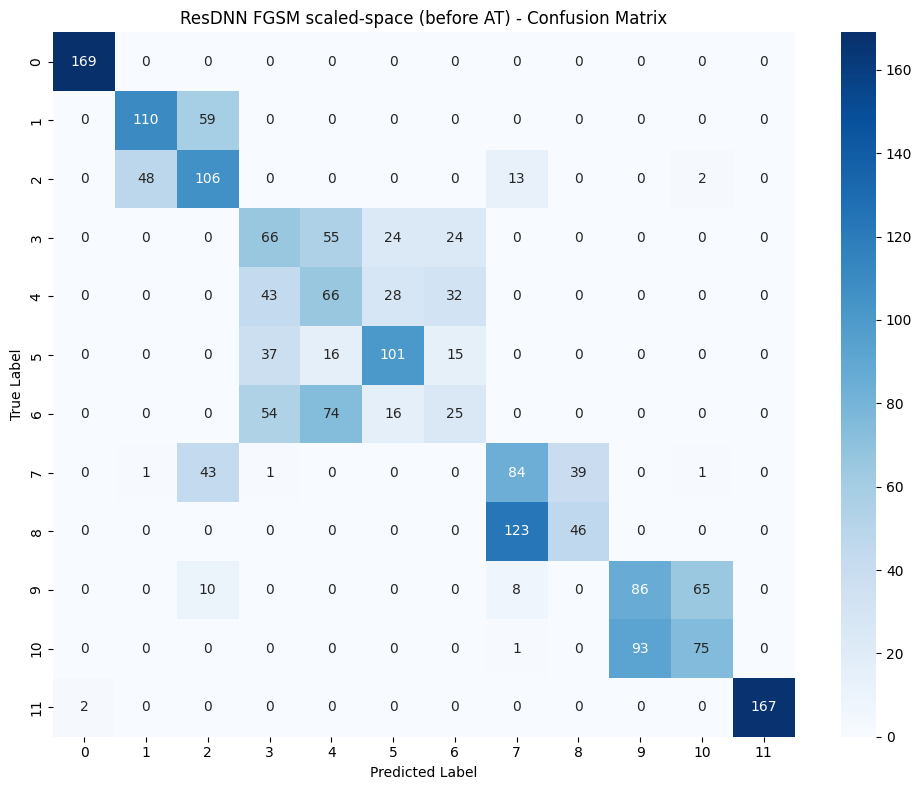

  Runtime: 1.75s



--- PGD scaled-space (before AT) ---
Accuracy: 39.64%
Precision: 41.48%
Recall: 39.64%
F1 Score: 0.3932


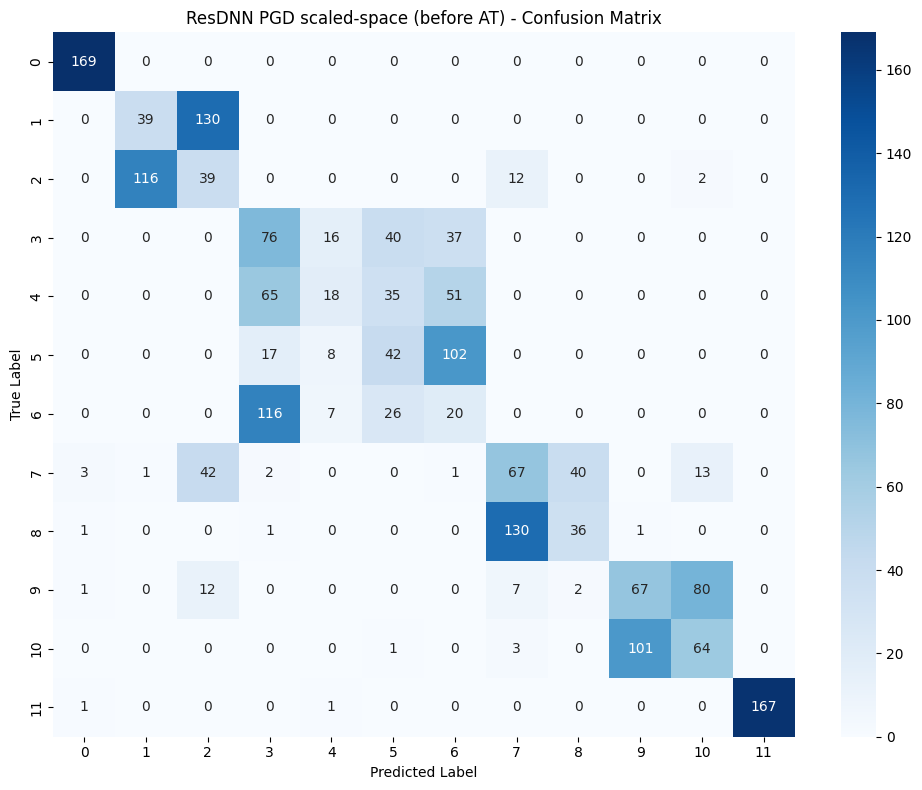

  Runtime: 157.29s



DeepFool: 100%|██████████| 32/32 [00:15<00:00,  2.06it/s]


--- DEEPFOOL scaled-space (before AT) ---
Accuracy: 20.76%
Precision: 23.11%
Recall: 20.76%
F1 Score: 0.2041


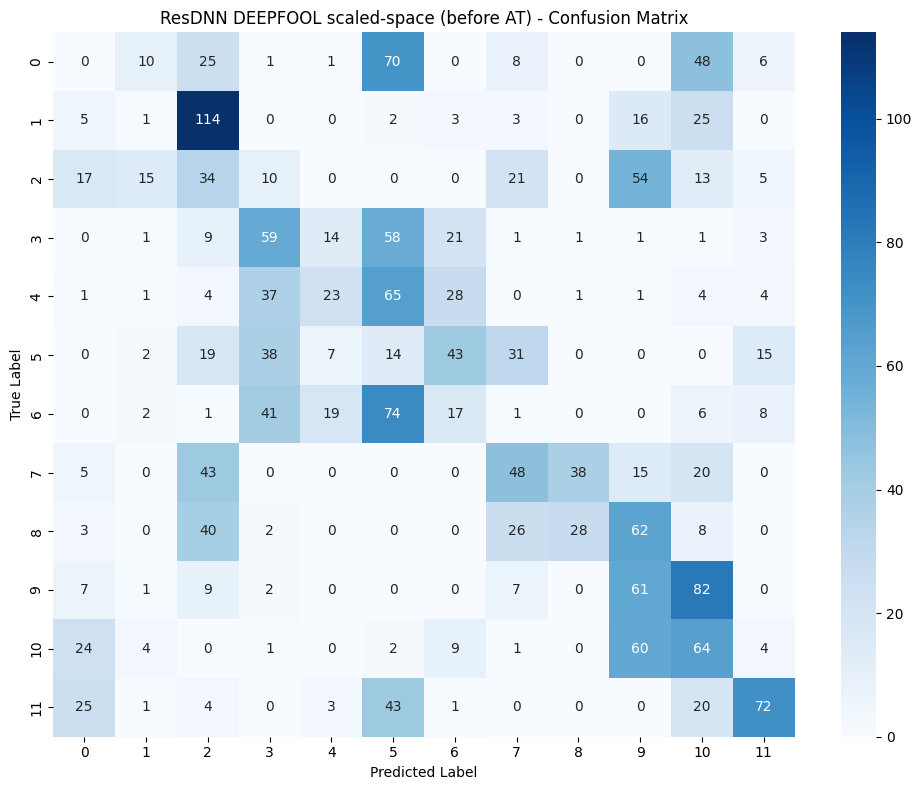

  Runtime: 15.78s

--- CW scaled-space (before AT) ---
Accuracy: 68.59%
Precision: 68.07%
Recall: 68.59%
F1 Score: 0.6732


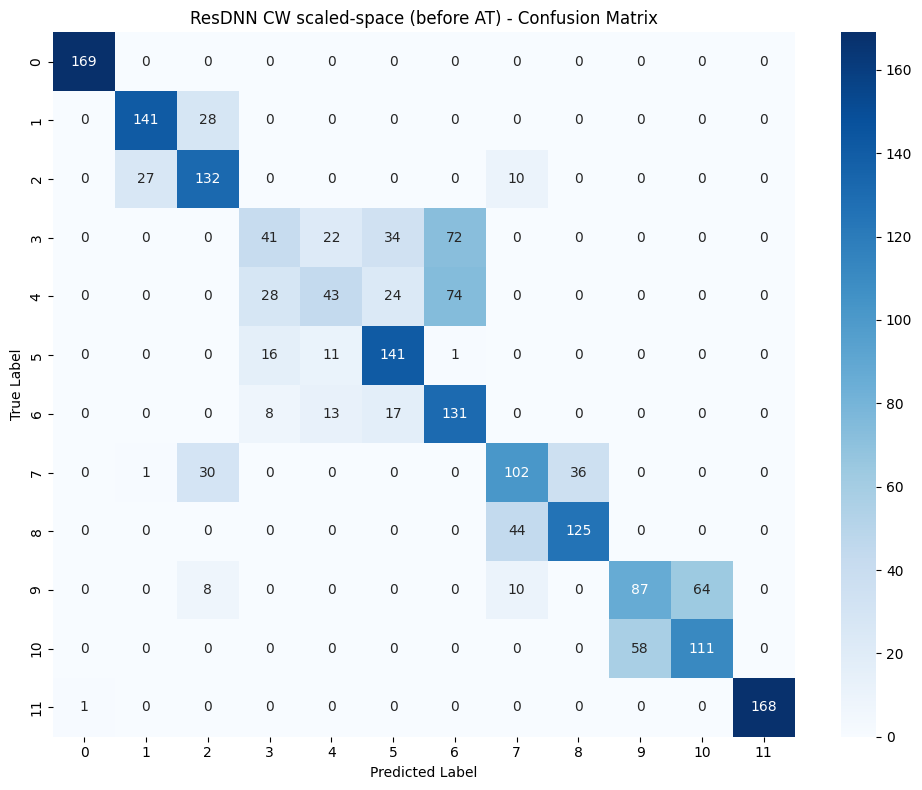

  Runtime: 49.34s



--- MIM scaled-space (before AT) ---
Accuracy: 40.63%
Precision: 42.24%
Recall: 40.63%
F1 Score: 0.4020


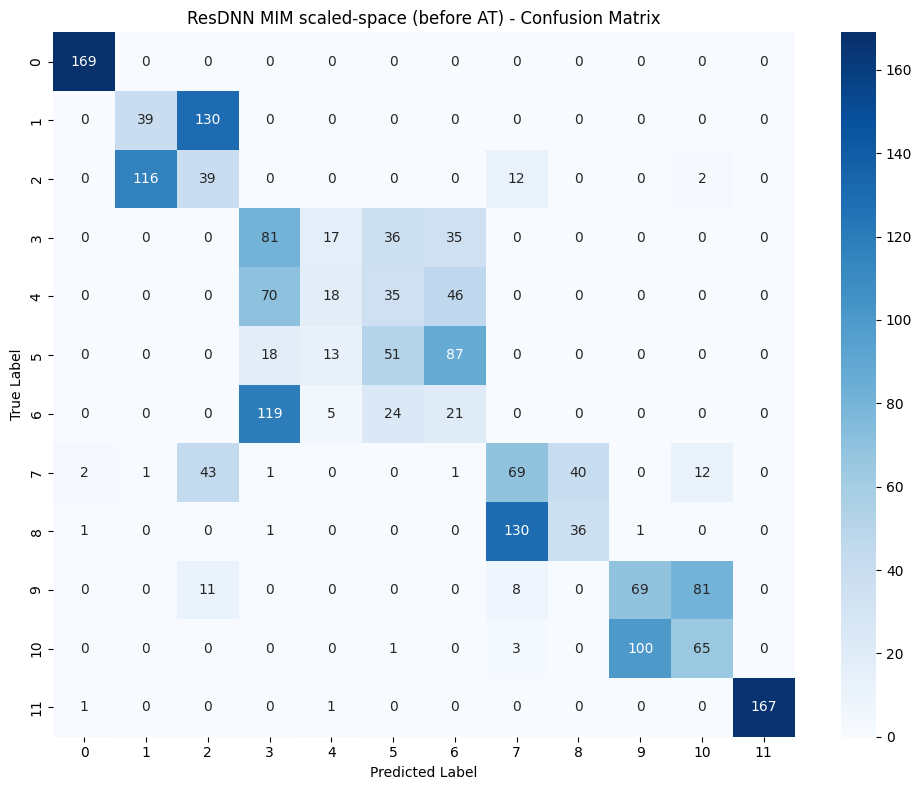

  Runtime: 71.36s



In [49]:
ADV_EVAL_SC_DIR = '../../adv_samples/adv_eval/resdnn_sc'
os.makedirs(ADV_EVAL_SC_DIR, exist_ok=True)

# Only WB attacks for scaled-space eval (ZOO/HSJA too slow to re-generate on test set)
eval_attacks = ['fgsm', 'pgd', 'deepfool', 'cw', 'mim']
adv_eval_data = {}

gen_cls_map = {
    'fgsm': FGSMAttackGenerator, 'pgd': PGDAttackGenerator,
    'deepfool': DeepFoolAttackGenerator, 'cw': CWAttackGenerator,
    'mim': MIMAttackGenerator,
}

for atk in eval_attacks:
    cfg = load_attack_config(atk)  # standard config for eval
    gen = gen_cls_map[atk](atk_clf, generator_params=cfg)

    start_time = time.time()
    df_adv_sc = gen.generate(X_test_sc, y_test, input_metadata_sc, mutate_indices=mutate_indices)
    elapsed = time.time() - start_time

    # Inverse transform to raw for CSV
    X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
    X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
    df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
    df_adv_raw['Label'] = y_test
    df_adv_raw.to_csv(os.path.join(ADV_EVAL_SC_DIR, f'resdnn_{atk}_adv.csv'), index=False)

    adv_eval_data[atk] = X_adv_raw

    preds_adv = raw_clf.predict(X_adv_raw)
    evaluate_attack(y_test, preds_adv, f'{atk.upper()} scaled-space (before AT)')
    print(f'  Runtime: {elapsed:.2f}s\n')

### 5. Generate adversarial training samples in SCALED space

Attack raw model with scaled inputs → eps uniform in standardized space → inverse_transform to raw for CSV.

In [11]:
# Load training data & scale
df_train = pd.read_csv('../../../datasets/augment/train_tvae_9600.csv')
X_train = df_train.drop(columns=['Label']).values.astype(np.float32)
y_train = df_train['Label'].values.astype(int)

X_train_sc = scaler.transform(X_train).astype(np.float32)

ADV_TRAIN_DIR = '../../adv_samples/adv_training/resdnn_sc'
os.makedirs(ADV_TRAIN_DIR, exist_ok=True)

print(f'Train set: {X_train.shape}')

Train set: (9600, 66)


#### FGSM (scaled space)

In [47]:
cfg = load_attack_config('fgsm')
gen = FGSMAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

# Inverse transform: scaled -> raw
X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'resdnn_fgsm_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

Runtime: 1.45s
Saved 9600 samples


#### PGD (scaled space)

In [48]:
cfg = load_attack_config('pgd')
gen = PGDAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'resdnn_pgd_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

Runtime: 64.42s
Saved 9600 samples


#### DeepFool (scaled space)

In [52]:
cfg = load_attack_config('deepfool')
gen = DeepFoolAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'resdnn_deepfool_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

DeepFool:   1%|▏         | 2/150 [00:00<00:34,  4.35it/s]

DeepFool: 100%|██████████| 150/150 [00:15<00:00,  9.86it/s]


Runtime: 15.89s
Saved 9600 samples


#### CW (scaled space)

In [ ]:
cfg = load_attack_config('cw')
gen = CWAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'resdnn_cw_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

Runtime: 578.49s
Saved 9600 samples


#### ZOO (scaled space, black-box)

In [ ]:
cfg = load_attack_config('zoo')
gen = ZooAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'resdnn_zoo_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

#### HSJA (scaled space, black-box)

In [ ]:
cfg = load_attack_config('hsja')
gen = HSJAAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'resdnn_hsja_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

#### MIM (scaled space)

In [ ]:
cfg = load_attack_config('mim')
gen = MIMAttackGenerator(atk_clf, generator_params=cfg)

start_time = time.time()
df_adv_sc = gen.generate(X_train_sc, y_train, input_metadata_sc, mutate_indices=mutate_indices)
print(f'Runtime: {time.time() - start_time:.2f}s')

X_adv_sc = df_adv_sc.drop(columns=['Label']).values.astype(np.float32)
X_adv_raw = scaler.inverse_transform(X_adv_sc).astype(np.float32)
df_adv_raw = pd.DataFrame(X_adv_raw, columns=feature_names)
df_adv_raw['Label'] = y_train
df_adv_raw.to_csv(os.path.join(ADV_TRAIN_DIR, 'resdnn_mim_train_adv.csv'), index=False)
print(f'Saved {len(df_adv_raw)} samples')

Runtime: 28.12s
Saved 9600 samples


### 6. Adversarial training — retrain ResDNN

In [ ]:
# Load & sample adversarial training data
CLEAN_ADV_RATIO = 1
n_clean = len(X_train)
n_adv_budget = int(n_clean / CLEAN_ADV_RATIO)

WB_ATTACKS = [
    ('fgsm',     1.5),
    ('pgd',      3.0),
    ('deepfool', 2.5),
    ('cw',       1.5),
    ('zoo',      1.0),
    ('hsja',     1.0),
    ('mim',      0.5),
]

total_weight = sum(w for _, w in WB_ATTACKS)
rng = np.random.RandomState(42)
parts_X, parts_y = [], []

print(f'Budget: {n_adv_budget} (clean={n_clean}, ratio={CLEAN_ADV_RATIO})\n')

for atk_name, weight in WB_ATTACKS:
    path = os.path.join(ADV_TRAIN_DIR, f'resdnn_{atk_name}_train_adv.csv')
    if not os.path.exists(path):
        print(f'  [SKIP] {path}')
        continue

    df = pd.read_csv(path)
    X_atk = df.drop(columns=['Label']).values.astype(np.float32)
    y_atk = df['Label'].values.astype(int)

    n_sample = int(n_adv_budget * weight / total_weight)
    n_sample = min(n_sample, len(X_atk))
    idx = rng.choice(len(X_atk), size=n_sample, replace=False)
    parts_X.append(X_atk[idx])
    parts_y.append(y_atk[idx])
    print(f'  {atk_name:>10s}: {len(X_atk)} -> {n_sample}  (weight={weight})')

# Merge & dedup
adv_X = np.concatenate(parts_X)
adv_y = np.concatenate(parts_y)

X_train_at = np.concatenate([X_train, adv_X])
y_train_at = np.concatenate([y_train, adv_y])

df_tmp = pd.DataFrame(X_train_at)
df_tmp['_lbl'] = y_train_at
n_before = len(df_tmp)
df_tmp = df_tmp.drop_duplicates()
X_train_at = df_tmp.drop(columns=['_lbl']).values.astype(np.float32)
y_train_at = df_tmp['_lbl'].values.astype(int)

print(f'\nClean: {n_clean} | Adv: {len(adv_X)} | Dedup: {n_before - len(df_tmp)}')
print(f'AT train: {X_train_at.shape}')
print(f'\nLabel distribution:\n{pd.Series(y_train_at).value_counts().sort_index()}')

Budget: 9600 (clean=9600, ratio=1)

        fgsm: 9600 -> 1309  (weight=1.5)
         pgd: 9600 -> 2618  (weight=3.0)


    deepfool: 9600 -> 2181  (weight=2.5)
          cw: 9600 -> 1309  (weight=1.5)
  [SKIP] ../../adv_samples/adv_training/resdnn_sc/resdnn_zoo_train_adv.csv
  [SKIP] ../../adv_samples/adv_training/resdnn_sc/resdnn_hsja_train_adv.csv
         mim: 9600 -> 436  (weight=0.5)

Clean: 9600 | Adv: 7853 | Dedup: 2
AT train: (17451, 66)

Label distribution:
0     1454
1     1444
2     1463
3     1467
4     1489
5     1426
6     1444
7     1464
8     1459
9     1479
10    1393
11    1469
Name: count, dtype: int64


In [18]:
# Scaler fit on clean+adv data
scaler_at = StandardScaler()
X_tr_at_sc = scaler_at.fit_transform(X_train_at).astype(np.float32)

# Stratified split 85/15
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
tr_idx, val_idx = next(sss.split(X_tr_at_sc, y_train_at))
X_tr_in, y_tr_in = X_tr_at_sc[tr_idx], y_train_at[tr_idx]
X_val, y_val = X_tr_at_sc[val_idx], y_train_at[val_idx]

# Sampler: balanced
counts_tr = np.bincount(y_tr_in, minlength=num_classes).astype(np.float32)
inv = counts_tr.sum() / (counts_tr + 1e-9)
inv /= inv.mean()
sample_w = inv[y_tr_in]
sampler = WeightedRandomSampler(weights=sample_w, num_samples=len(sample_w), replacement=True)

# DataLoaders
BATCH_SIZE = 1024
Xtr_t = torch.from_numpy(X_tr_in)
ytr_t = torch.from_numpy(y_tr_in).long()
Xva_t = torch.from_numpy(X_val.astype(np.float32))
yva_t = torch.from_numpy(y_val).long()

train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(TensorDataset(Xva_t, yva_t), batch_size=4096, shuffle=False)

# CB-Focal Loss
def cb_class_weights(counts, beta=0.999):
    eff = (1.0 - beta) / (1.0 - np.power(beta, counts + 1e-12))
    w = eff / eff.mean()
    return torch.tensor(w, dtype=torch.float32)

class FocalCE(nn.Module):
    def __init__(self, gamma=1.7, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing
    def forward(self, logits, target):
        n_classes = logits.size(1)
        logp = torch.log_softmax(logits, dim=1)
        p = torch.exp(logp)
        if self.label_smoothing > 0:
            smooth = self.label_smoothing / n_classes
            one_hot = torch.zeros_like(logp).scatter_(1, target.unsqueeze(1), 1.0)
            soft_target = one_hot * (1.0 - self.label_smoothing) + smooth
        else:
            soft_target = torch.zeros_like(logp).scatter_(1, target.unsqueeze(1), 1.0)
        idx = torch.arange(logits.size(0), device=logits.device)
        pt = p[idx, target]
        focal_weight = (1 - pt) ** self.gamma
        loss = -(soft_target * logp).sum(dim=1) * focal_weight
        if self.weight is not None:
            loss = loss * self.weight.to(logits.device)[target]
        return loss.mean()

LABEL_SMOOTHING = 0.05
cls_w = cb_class_weights(counts_tr, beta=0.999).to(DEVICE)
criterion = FocalCE(gamma=1.7, weight=cls_w, label_smoothing=LABEL_SMOOTHING)

# Train
torch.manual_seed(42)
resdnn_at = _ResDNN(in_dim=input_dim, n_classes=num_classes).to(DEVICE)

total_epochs = 200
warmup_epochs = 8
LR = 1e-3
optimizer = torch.optim.AdamW(resdnn_at.parameters(), lr=LR, weight_decay=2e-4)

steps_per_epoch = max(1, len(train_loader))
def lr_lambda(current_step):
    warmup_steps = warmup_epochs * steps_per_epoch
    total_steps = total_epochs * steps_per_epoch
    if current_step < warmup_steps:
        return (current_step + 1) / warmup_steps
    progress = (current_step - warmup_steps) / max(1, (total_steps - warmup_steps))
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

best_f1, best_state, wait, patience = -1.0, None, 0, 20

for epoch in range(total_epochs):
    resdnn_at.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(resdnn_at(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(resdnn_at.parameters(), 3.0)
        optimizer.step()
        scheduler.step()

    resdnn_at.eval()
    all_preds = []
    with torch.no_grad():
        for xb, _ in val_loader:
            preds = torch.argmax(resdnn_at(xb.to(DEVICE)), dim=1).cpu().numpy()
            all_preds.extend(preds)

    val_f1 = f1_score(y_val, all_preds, average='macro', zero_division=0)
    if val_f1 > best_f1:
        best_f1, wait = val_f1, 0
        best_state = {k: v.detach().cpu().clone() for k, v in resdnn_at.state_dict().items()}
    else:
        wait += 1
    if wait >= patience:
        print(f'Early stop at epoch {epoch + 1} | best VAL Macro-F1 = {best_f1:.4f}')
        break
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{total_epochs}, val_f1={val_f1:.4f}')

if best_state is not None:
    resdnn_at.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()}, strict=True)
resdnn_at.eval()
print(f'Training done. Best val F1: {best_f1:.4f}')

Epoch 10/200, val_f1=0.5502
Epoch 20/200, val_f1=0.6428
Epoch 30/200, val_f1=0.6321
Epoch 40/200, val_f1=0.6774
Epoch 50/200, val_f1=0.6816
Epoch 60/200, val_f1=0.7028
Epoch 70/200, val_f1=0.6862
Epoch 80/200, val_f1=0.7007
Epoch 90/200, val_f1=0.6995
Epoch 100/200, val_f1=0.7124
Epoch 110/200, val_f1=0.7304
Epoch 120/200, val_f1=0.7051
Epoch 130/200, val_f1=0.7216
Epoch 140/200, val_f1=0.7135
Early stop at epoch 144 | best VAL Macro-F1 = 0.7307
Training done. Best val F1: 0.7307


In [19]:
# Save checkpoint
os.makedirs('../../defense/exp/models', exist_ok=True)
out_path = '../../defense/exp/models/framework_resdnn_TVAE_at.pth'

torch.save({
    'state_dict':   resdnn_at.state_dict(),
    'in_dim':       input_dim,
    'n_classes':    num_classes,
    'scaler':       scaler_at,
    'scaler_mean':  scaler_at.mean_,
    'scaler_scale': scaler_at.scale_,
}, out_path)
print(f'Saved: {out_path}')

Saved: ../../defense/exp/models/framework_resdnn_TVAE_at.pth


### 7. Evaluate retrained model

--- Original (after AT) ---
Accuracy: 69.08%
Precision: 69.72%
Recall: 69.08%
F1 Score: 0.6760


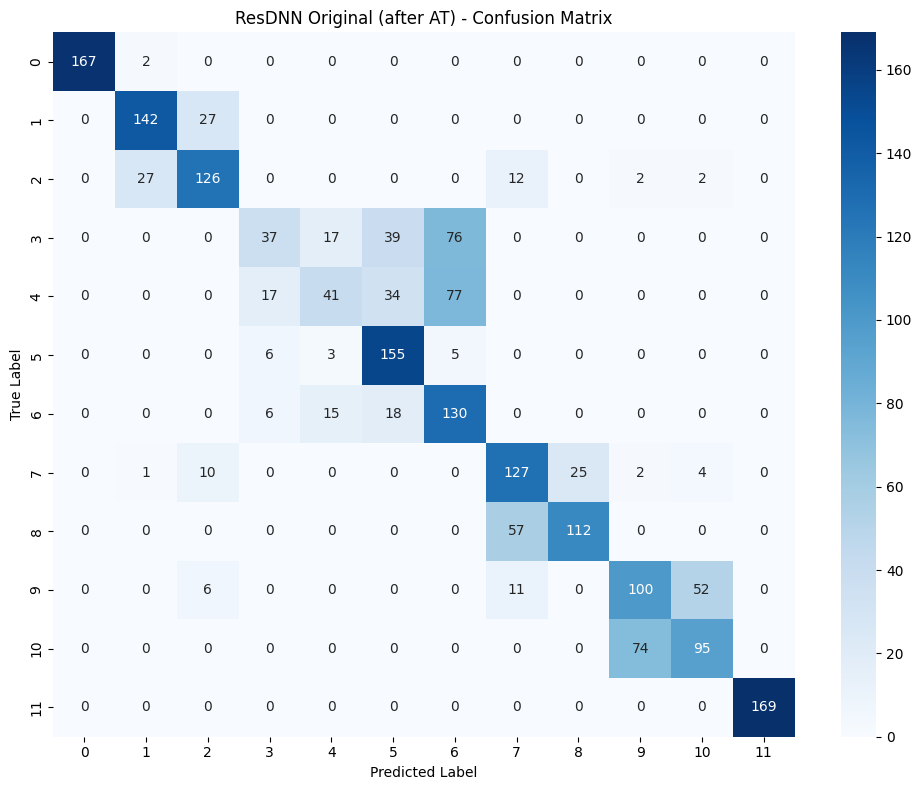

--- FGSM (after AT) ---
Accuracy: 68.24%
Precision: 68.13%
Recall: 68.24%
F1 Score: 0.6666


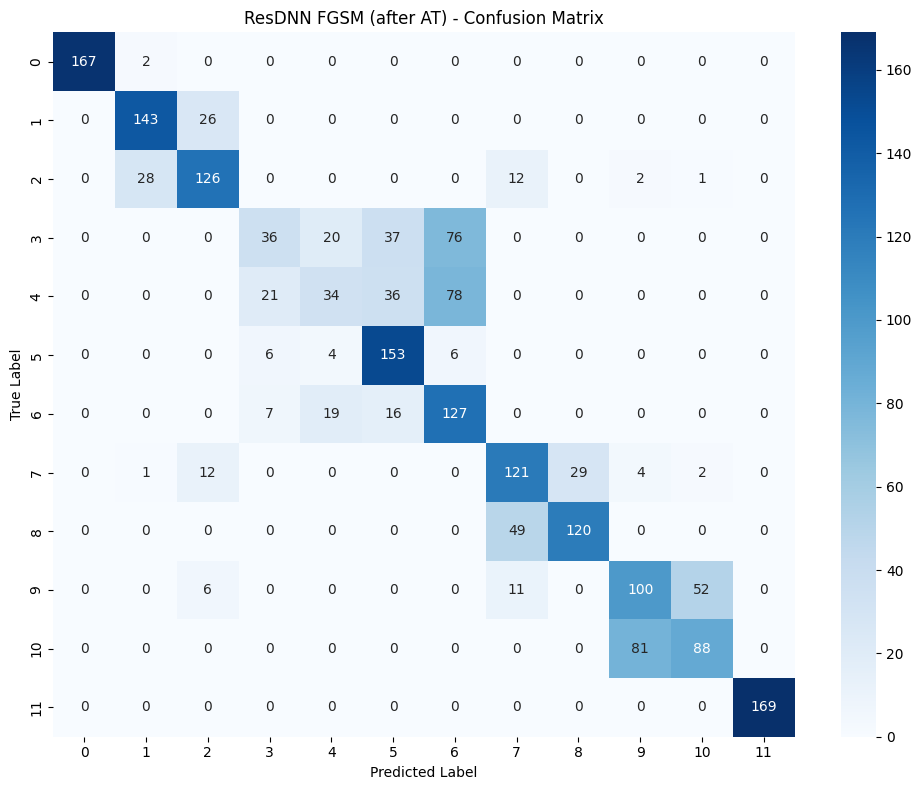

--- PGD (after AT) ---
Accuracy: 68.93%
Precision: 69.17%
Recall: 68.93%
F1 Score: 0.6760


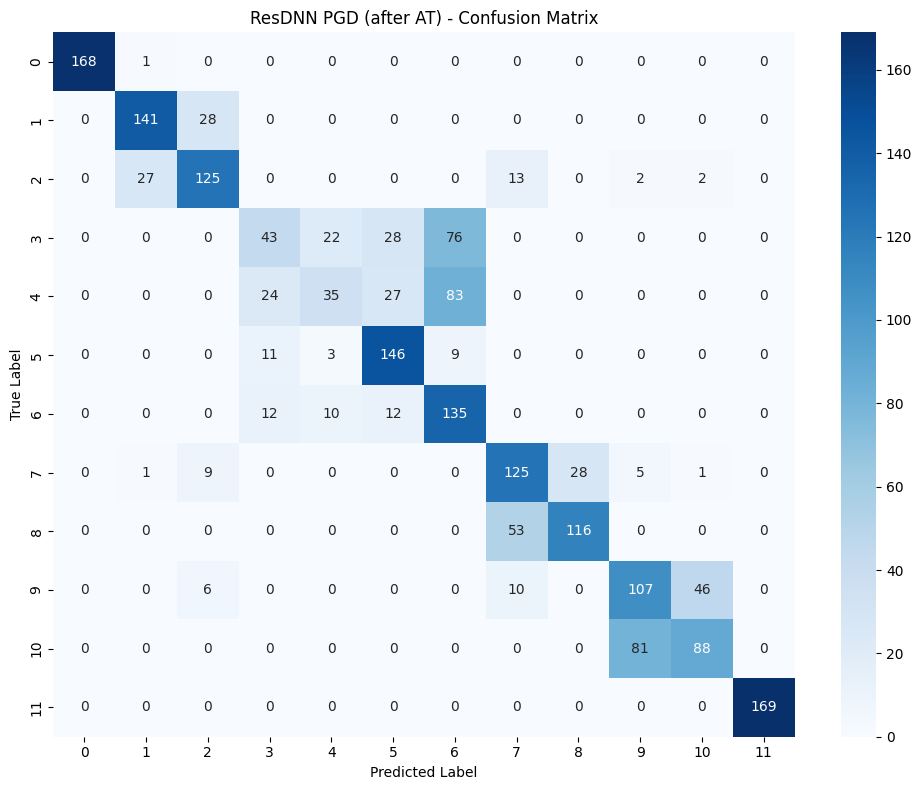

--- DEEPFOOL (after AT) ---
Accuracy: 67.06%
Precision: 66.57%
Recall: 67.06%
F1 Score: 0.6660


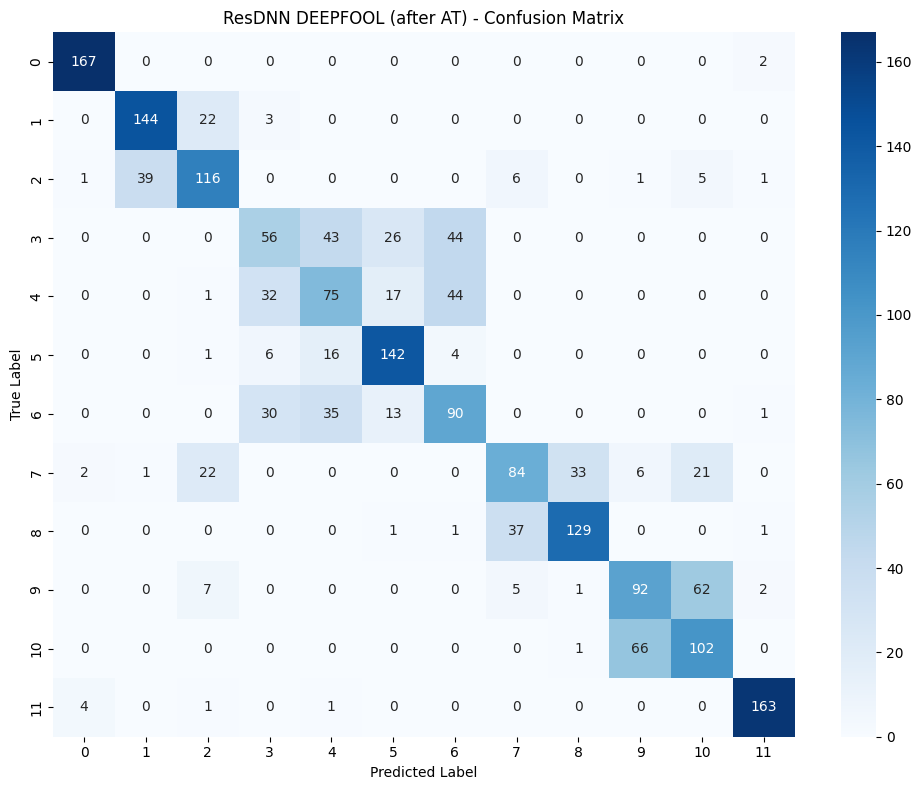

--- CW (after AT) ---
Accuracy: 69.08%
Precision: 69.68%
Recall: 69.08%
F1 Score: 0.6760


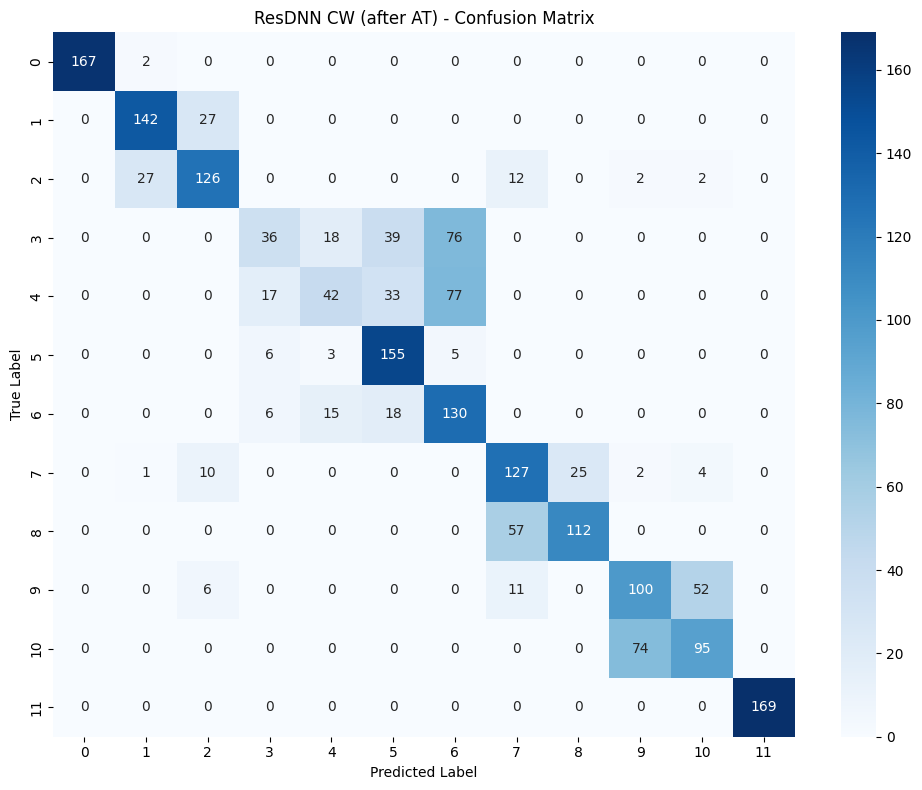

--- MIM (after AT) ---
Accuracy: 69.28%
Precision: 69.50%
Recall: 69.28%
F1 Score: 0.6803


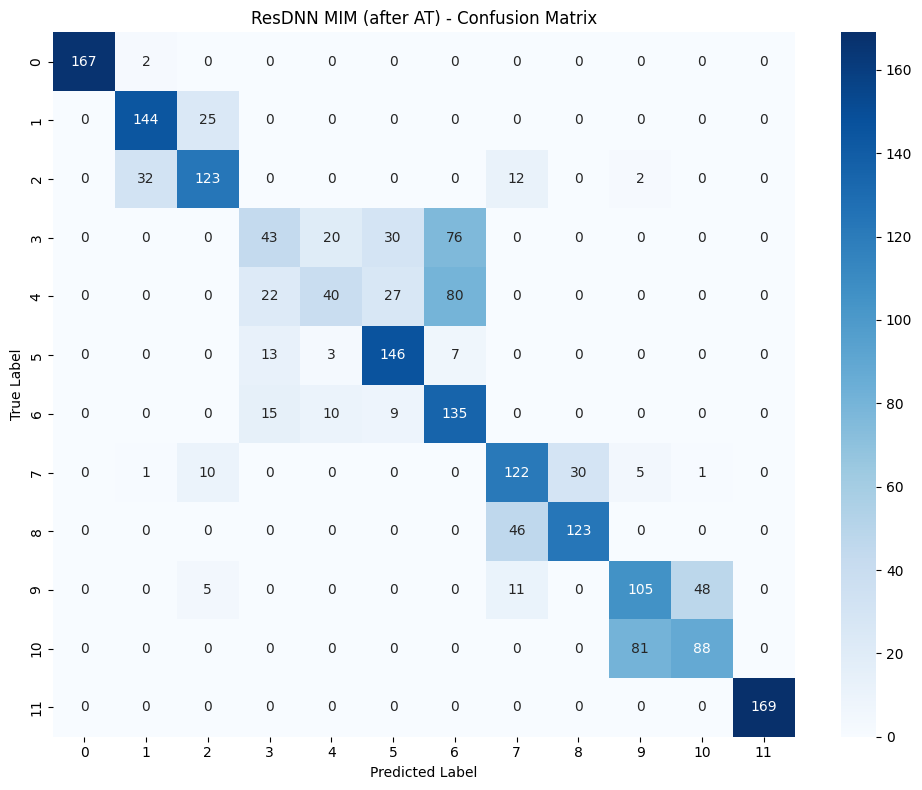

In [51]:
# Load retrained AT model
ckpt_at = torch.load(out_path, map_location=DEVICE, weights_only=False)

resdnn_at_net = _ResDNN(in_dim=int(ckpt_at['in_dim']), n_classes=int(ckpt_at['n_classes']))
resdnn_at_net.load_state_dict(ckpt_at['state_dict'])
resdnn_at_net.eval()

# Wrap with _Scaled for raw-space evaluation
scaled_model_at = _ScaledResDNN(resdnn_at_net, ckpt_at['scaler_mean'], ckpt_at['scaler_scale']).to(DEVICE)
scaled_model_at.eval()

classifier_at = PyTorchClassifier(
    model=scaled_model_at,
    loss=nn.CrossEntropyLoss(),
    input_shape=(input_dim,),
    nb_classes=num_classes,
    clip_values=(float(X_test.min()), float(X_test.max())),
    device_type=DEVICE,
)

# Evaluate on original test data
preds_orig = classifier_at.predict(X_test)
evaluate_attack(y_test, preds_orig, 'Original (after AT)')

# Evaluate on each adversarial test set
for atk, adv_data in adv_eval_data.items():
    preds_adv = classifier_at.predict(adv_data)
    evaluate_attack(y_test, preds_adv, f'{atk.upper()} (after AT)')

### 8. ASR comparison

In [50]:
# Before AT
preds_before = raw_clf.predict(X_test)
y_pred_before = np.argmax(preds_before, axis=1)
correct_before = np.where(y_test == y_pred_before)[0]

# After AT
preds_after = classifier_at.predict(X_test)
y_pred_after = np.argmax(preds_after, axis=1)
correct_after = np.where(y_test == y_pred_after)[0]

print('=== ResDNN ASR Comparison: Scaled-Space AT (Before -> After) ===')
for atk, adv_data in adv_eval_data.items():
    preds_adv_b = np.argmax(raw_clf.predict(adv_data), axis=1)
    asr_before = np.sum(y_pred_before[correct_before] != preds_adv_b[correct_before]) / len(correct_before) * 100

    preds_adv_a = np.argmax(classifier_at.predict(adv_data), axis=1)
    asr_after = np.sum(y_pred_after[correct_after] != preds_adv_a[correct_after]) / len(correct_after) * 100

    print(f'{atk.upper():>10s} ASR: {asr_before:.2f}% -> {asr_after:.2f}%')

=== ResDNN ASR Comparison: Scaled-Space AT (Before -> After) ===
      FGSM ASR: 49.96% -> 3.78%
       PGD ASR: 72.08% -> 4.14%
  DEEPFOOL ASR: 94.56% -> 16.35%
        CW ASR: 4.08% -> 0.07%
       MIM ASR: 71.30% -> 4.35%
